In [1]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch
import argparse
from nnfabrik.builder import get_data, get_trainer

from modified_neuralpredictors.create_model import stacked_core_full_gauss_readout
from modified_neuralpredictors.wandb_trainer import standard_trainer

random_seed = 42
torch.manual_seed(random_seed)
np.random.seed(random_seed)

device = 'cuda:0'
torch.cuda.set_device(device)

basepath = "/srv/user/polina/sensorium/sensorium/notebooks/data/"

# as filenames, we'll select all 7 datasets
filenames = [
    os.path.join(basepath, file) for file in os.listdir(basepath) if ".zip" in file
]

dataset_fn = "sensorium.datasets.static_loaders"
dataset_config = {
    "paths": filenames,
    "normalize": True,
    "include_behavior": True,
    "include_eye_position": True,
    "batch_size": 128,
    "scale": 0.25,
}

dataloaders = get_data(dataset_fn, dataset_config)
data_keys = list(dataloaders['train'].keys())

model_config = {
    'hidden_channels': 64, # original sensorium was 64ch
    'depth_separable': False,
    'use_avg_reg': False,
    'laplace_padding': None,
    'momentum': 0.75,
    'final_nonlinearity': True,
    'nonlinearity_type': 'AdaptiveELU',
    'pad_input': False,
    'stack': -1,
    'layers': 4,
    'input_kern': 11, #  original sensorium was 'input_kern': 9,
    'gamma_input': 6.3831, # this should not influence the performance based on previous experience
    
    'feature_reg_weight': 3, # this is the one I actually would like to tune!
    
    'hidden_kern': 7,
    'grid_mean_predictor': {
        'type': 'cortex',
        'input_dimensions': 2,
        'hidden_layers': 1,
        'hidden_features': 30,
        'final_tanh': True
    },
    
    'init_sigma': 0.1,
    'init_mu_range': 0.3,
    'gauss_type': 'full',
    'shifter': True,
    'batch_norm_scale': [True, True, True, False],
    'core_bias': [True, True, True, False],
    'regularizer_type': "adaptive_log_norm",
    'gamma_sigma' : 0.25,
}

In [2]:
base_reg3_path = 'runs/newbase/dim64_seed0/model_weights.pth'
base_reg1_path = 'runs/newbase/base_regw1_seed0/model_weights.pth'
seeds = [3, 10, 17, 29, 31, 43]
read_reg3_paths = [
    'runs/readout_consistency/baseseed0_seed3/model_weights.pth',
    'runs/readout_consistency/baseseed0_seed10/model_weights.pth',
    'runs/readout_consistency/baseseed0_seed17/model_weights.pth',
    'runs/readout_consistency/baseseed0_seed29/model_weights.pth',
    'runs/readout_consistency/baseseed0_seed31/model_weights.pth',
    'runs/readout_consistency/baseseed0_seed43/model_weights.pth',
]

read_reg1_paths = [
    'runs/readout_consistency/basereg1_seed3/model_weights.pth',
    'runs/readout_consistency/basereg1_seed10/model_weights.pth',
    'runs/readout_consistency/basereg1_seed17/model_weights.pth',
    'runs/readout_consistency/basereg1_seed29/model_weights.pth',
    'runs/readout_consistency/basereg1_seed31/model_weights.pth',
    'runs/readout_consistency/basereg1_seed43/model_weights.pth',
]

In [3]:
paths = read_reg3_paths

readouts = [[] for _ in range(len(paths))]
for i, path in enumerate(paths):
    for k, v in torch.load(path).items():
        if 'readout' in k and 'features' in k:
            readouts[i].append(v.cpu().squeeze().T)
    readouts[i] = torch.cat(readouts[i])
readouts = torch.stack(readouts)

dists = (readouts[None, :, :, :] - readouts[:, None, :, :]).pow(2).sum(dim=-1).sqrt()

In [4]:
(readouts - readouts.mean(1, keepdim=True)).pow(2).sum(-1).sqrt().mean(1)

tensor([1.0395, 1.0359, 1.0475, 1.0424, 1.0413, 1.0349])

In [5]:
i, j = torch.tril_indices(6, 6, -1)
dists[i, j].mean()

tensor(0.2979)

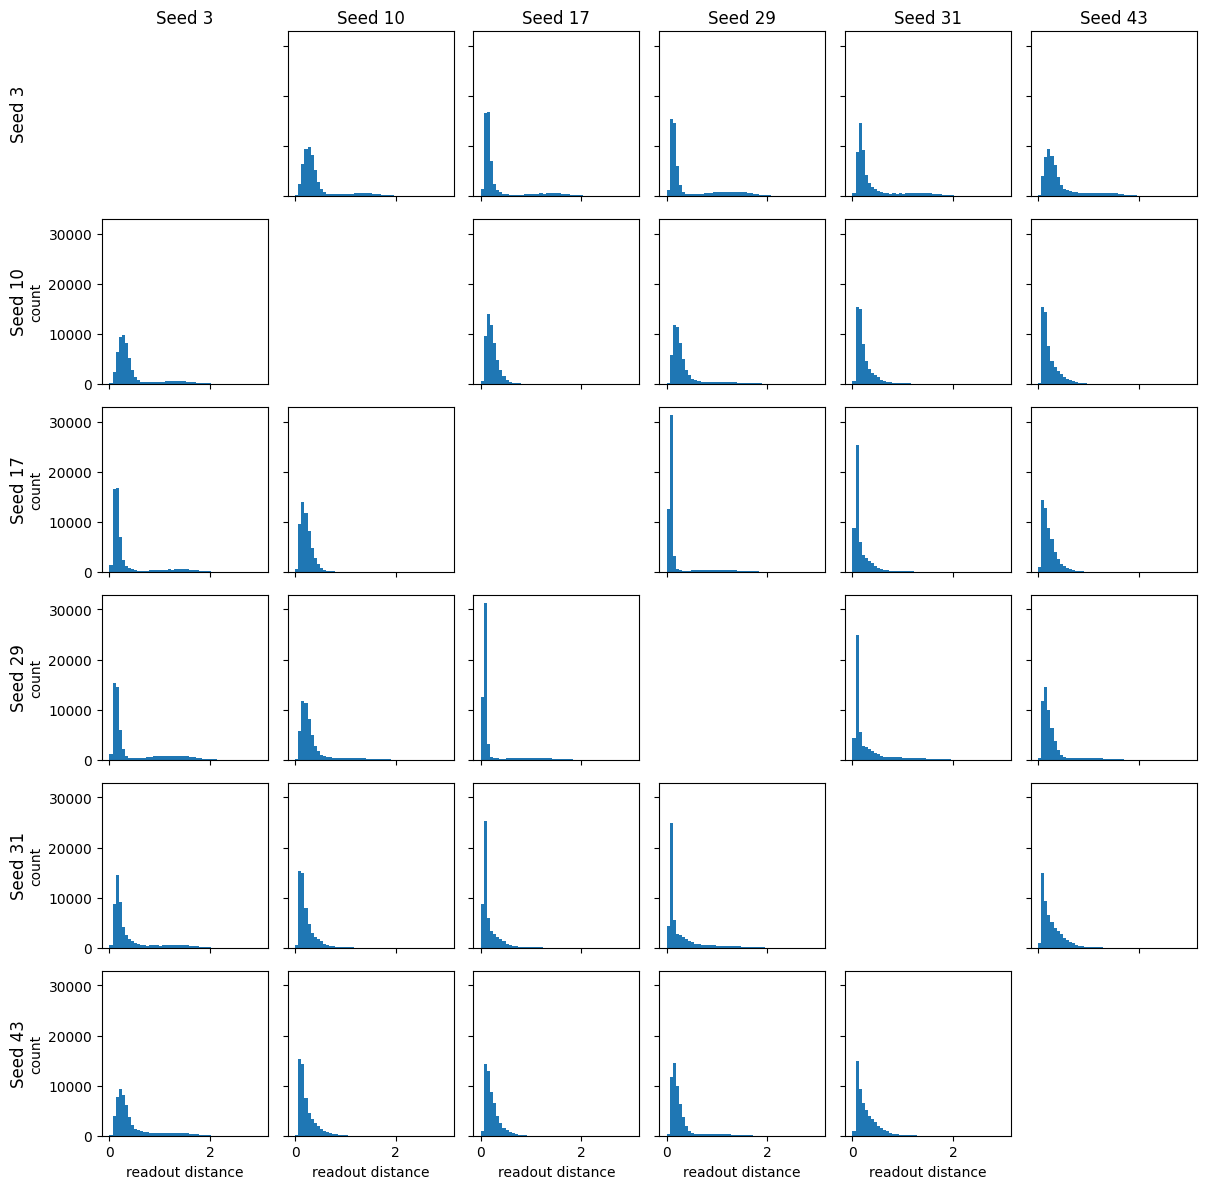

In [6]:
n = readouts.shape[0]
fig, axs = plt.subplots(n, n, figsize=(12, 12), sharey=True, sharex=True)

bins = torch.linspace(0, 3, steps=50)

# Example seed labels
seed_labels = [f"Seed {seed}" for seed in seeds]

for i in range(n):
    for j in range(n):
        ax = axs[i, j]

        # Axis labels
        if i == n - 1:
            ax.set_xlabel("readout distance")
        if j == 0:
            ax.set_ylabel("count")

        # Column labels (top row)
        if i == 0:
            ax.set_title(seed_labels[j])

        # Row labels (left side)
        if j == 0:
            ax.annotate(
                seed_labels[i],
                xy=(-0.5, 0.5),
                xycoords='axes fraction',
                rotation=90,
                va='center',
                ha='center',
                fontsize=12
            )

        if i == j:
            ax.axis("off")
            continue

        ax.hist(dists[i, j], bins=bins)

plt.tight_layout()
plt.show()

In [7]:
from utils.knn import get_curve

k_range = np.unique(np.geomspace(1, 100, num=20, dtype=int))
m, s, curves = get_curve(readouts, k_range)

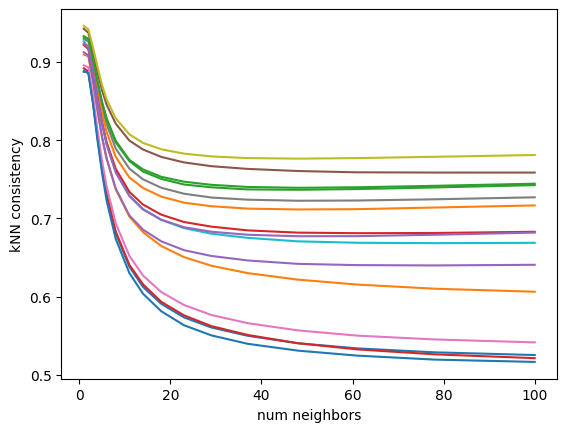

In [8]:
for curve in curves.T:
    plt.plot(k_range, curve)
plt.ylabel('kNN consistency')
plt.xlabel('num neighbors')
plt.show()

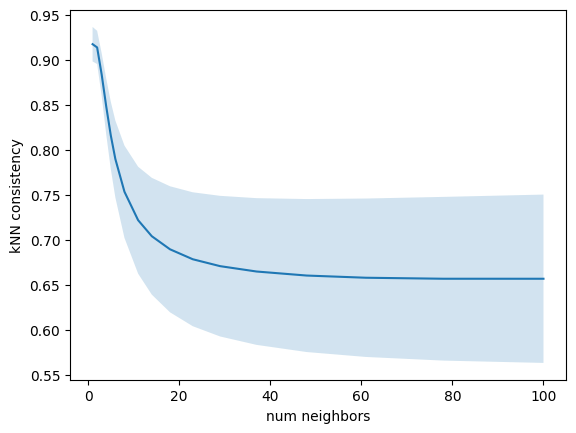

In [14]:
plt.plot(k_range, m)
plt.fill_between(k_range, m - s, m + s, alpha=0.2)

plt.ylabel('kNN consistency')
plt.xlabel('num neighbors')
plt.show()

In [12]:
consistencies = curves[-1]

# output correlation vs knn consistency

In [15]:
paths = read_reg3_paths

num_batches = 5
preds = [
    [[] for _ in range(7)] 
    for _ in range(len(paths))
]
targets = [
    [[] for _ in range(7)] 
    for _ in range(len(paths))
]
models = []

for path in paths:
    model = stacked_core_full_gauss_readout(dataloaders, random_seed, **model_config)
    model.load_state_dict(torch.load(path, map_location=device))
    model.to(device)
    model.train()
    models.append(model)

for i, key in enumerate(data_keys):
    batch_count = 0
    for batch in dataloaders['validation'][key]:
        batch_count += 1
        img, target, _, pupil = batch
        
        for j, model in enumerate(models):
            with torch.no_grad():
                pred = model(img, data_key=key, pupil_center=pupil).cpu()
                preds[j][i].append(pred)
            targets[j][i].append(target.cpu())
        
        if batch_count == num_batches:
            break

for i in range(len(paths)):
    for j in range(7):
        preds[i][j] = torch.cat(preds[i][j])
        targets[i][j] = torch.cat(targets[i][j])
    # preds[i] = torch.cat(preds[i], dim=1)
    # targets[i] = torch.cat(targets[i], dim=1)

Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
/srv/user/nathanpaul.soeding/neuralpredictors/neuralpredictors/layers/readouts/base.py:95: UserWarning: Readout is NOT initialized with mean activity but with 0!
  warnings.warn("Readout is NOT initialized with mean activity but with 0!")
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.


In [16]:
idcs, jdcs = torch.tril_indices(len(paths), len(paths), offset=-1)
corrs = []
for i, j in zip(idcs, jdcs):
    pair_corrs = []
    for k in range(7):
        X = preds[i][k].T
        Y = preds[j][k].T

        corr = torch.nn.functional.cosine_similarity(
            X - X.mean(0, keepdim=True),
            Y - Y.mean(0, keepdim=True),
            dim=0
        )
        pair_corrs.append(corr)
    corrs.append(torch.cat(pair_corrs))

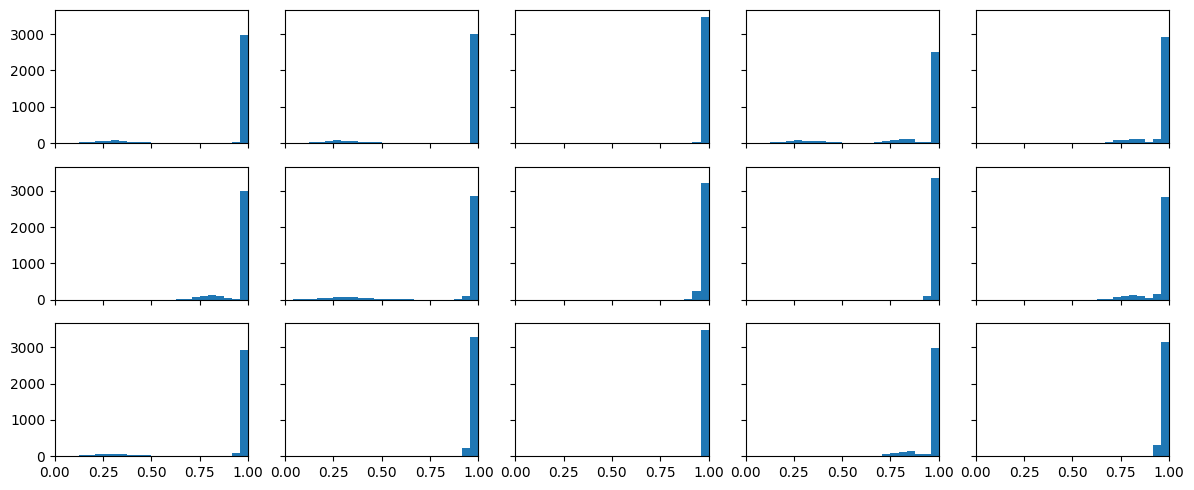

In [17]:
fig, axs = plt.subplots(3, 5, figsize=(12, 5), sharex=True, sharey=True)
for ax, corr in zip(axs.flatten(), corrs):
    ax.hist(corr, bins=torch.linspace(0, 1, steps=25))
    ax.set_xlim(0, 1)
plt.tight_layout()

In [18]:
mean_corrs = torch.stack(corrs).mean(dim=1)

In [24]:
np.tril_indices(6, k=-1)

(array([1, 2, 2, 3, 3, 3, 4, 4, 4, 4, 5, 5, 5, 5, 5]),
 array([0, 0, 1, 0, 1, 2, 0, 1, 2, 3, 0, 1, 2, 3, 4]))

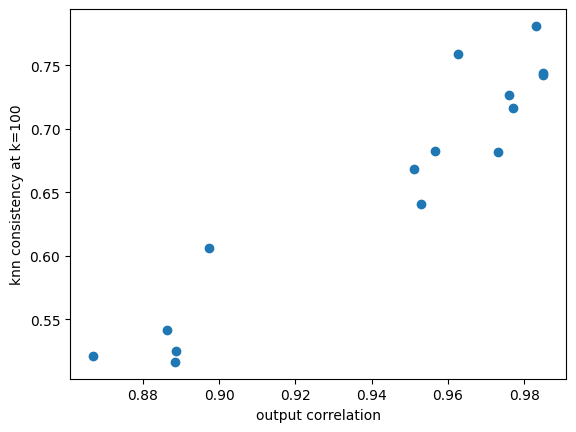

In [22]:
plt.scatter(mean_corrs, consistencies)
plt.xlabel('output correlation')
plt.ylabel('knn consistency at k=100')
plt.show()